Imports & Setup

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
sns.set_theme(style="whitegrid")
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

Load Data

In [5]:
FILE_PATH = "data/separated_data.xlsx"
 
customers     = pd.read_excel(FILE_PATH, sheet_name="Customers")
leads         = pd.read_excel(FILE_PATH, sheet_name="Leads")
organizations = pd.read_excel(FILE_PATH, sheet_name="Organizations")
people        = pd.read_excel(FILE_PATH, sheet_name="People")
products      = pd.read_excel(FILE_PATH, sheet_name="Products")
 
print("Customers:", customers.shape)
print("Leads:", leads.shape)
print("Organizations:", organizations.shape)
print("People:", people.shape)
print("Products:", products.shape)

Customers: (10000, 12)
Leads: (10000, 14)
Organizations: (10000, 9)
People: (10000, 9)
Products: (10000, 13)


Quick Cleaning for visualization

In [6]:
# Customers
customers["Subscription Date"] = pd.to_datetime(customers["Subscription Date"], errors="coerce")
customers["sub_year"]  = customers["Subscription Date"].dt.year
customers["sub_month"] = customers["Subscription Date"].dt.to_period("M")
 
# Products
products["Price"] = pd.to_numeric(products["Price"], errors="coerce")
products["Stock"] = pd.to_numeric(products["Stock"], errors="coerce")
 
# Organizations
organizations["Number of employees"] = pd.to_numeric(organizations["Number of employees"], errors="coerce")
organizations["Founded"]             = pd.to_numeric(organizations["Founded"], errors="coerce")
 
# People
people["Date of birth"] = pd.to_datetime(people["Date of birth"], errors="coerce")
people["age"] = (pd.Timestamp.today() - people["Date of birth"]).dt.days // 365

Cleaning done.


Products

Top 15 categories by count

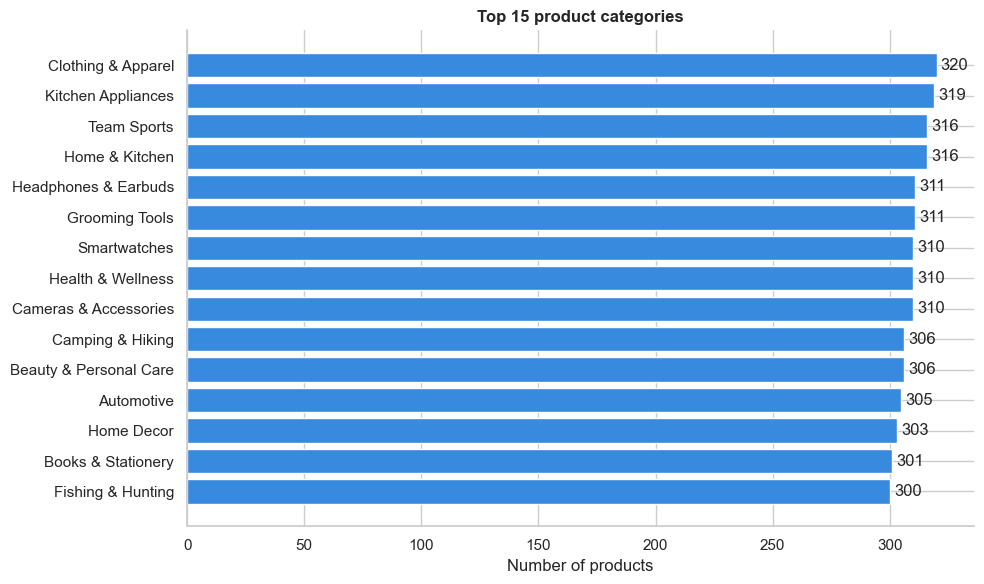

In [7]:
cat_counts = products["Category"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(cat_counts.index[::-1], cat_counts.values[::-1], color="#378ADD")
plt.bar_label(bars, padding=3)
plt.title("Top 15 product categories", fontweight="bold")
plt.xlabel("Number of products")
plt.tight_layout()
plt.show()

Availability status

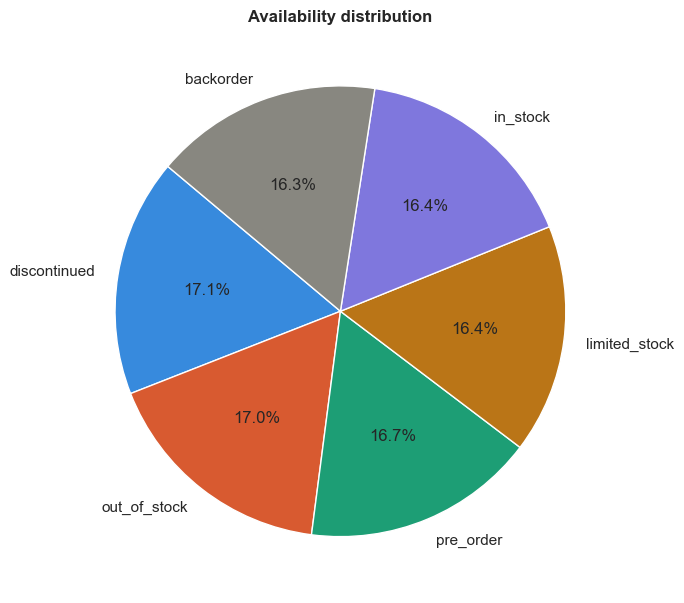

In [8]:
avail = products["Availability"].value_counts()
 
plt.figure(figsize=(7, 7))
plt.pie(avail.values, labels=avail.index, autopct="%1.1f%%", startangle=140,
        colors=["#378ADD","#D85A30","#1D9E75","#BA7517","#7F77DD","#888780"])
plt.title("Availability distribution", fontweight="bold")
plt.tight_layout()
plt.show()

Price distribution

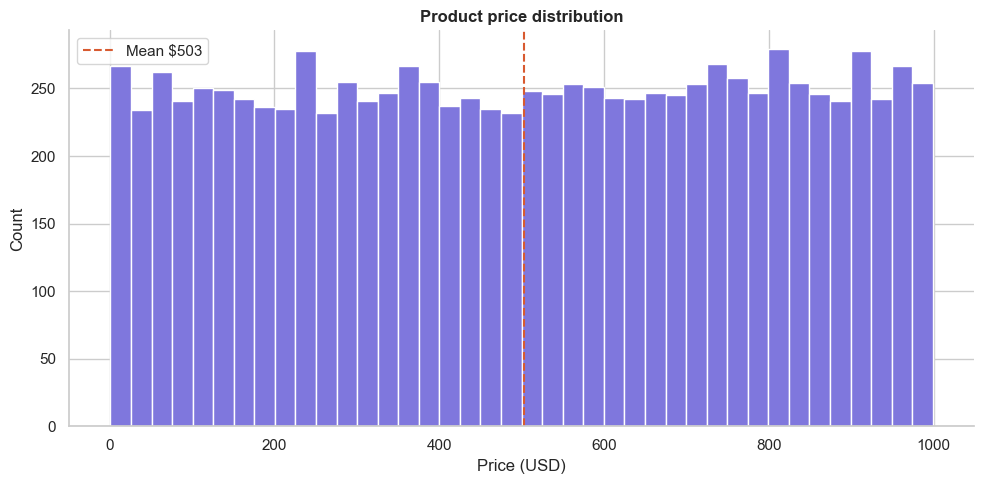

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(products["Price"].dropna(), bins=40, color="#7F77DD", edgecolor="white")
plt.axvline(products["Price"].mean(), color="#D85A30", linestyle="--",
            label=f"Mean ${products['Price'].mean():.0f}")
plt.title("Product price distribution", fontweight="bold")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Avg price per top 10 categories

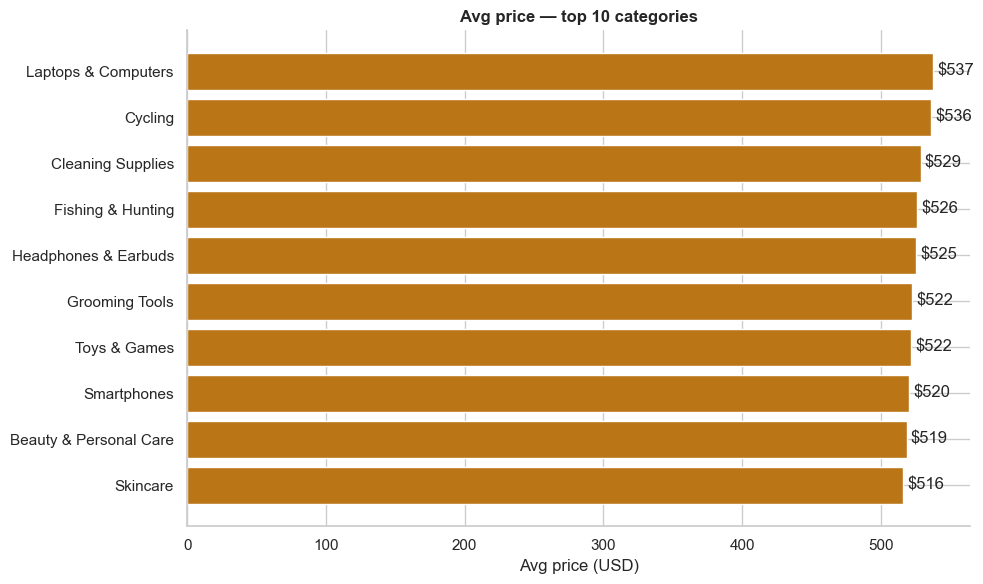

In [10]:
avg_price = products.groupby("Category")["Price"].mean().sort_values(ascending=False).head(10)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(avg_price.index[::-1], avg_price.values[::-1], color="#BA7517")
plt.bar_label(bars, fmt="$%.0f", padding=3)
plt.title("Avg price — top 10 categories", fontweight="bold")
plt.xlabel("Avg price (USD)")
plt.tight_layout()
plt.show()

Customers

Subscriptions by year

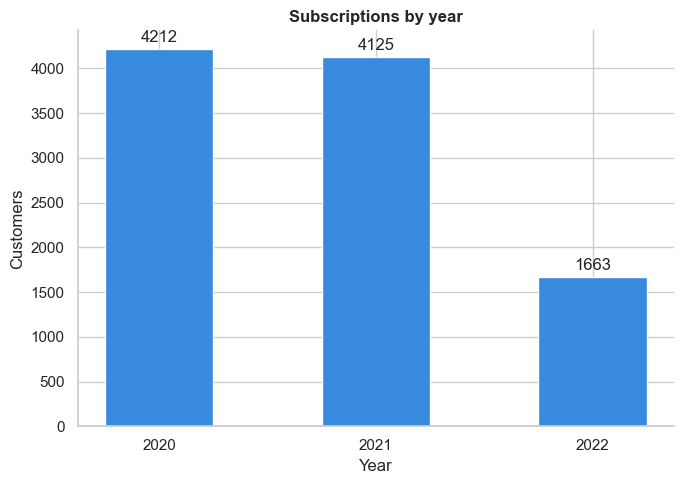

In [11]:
year_counts = customers["sub_year"].value_counts().sort_index()
 
plt.figure(figsize=(7, 5))
bars = plt.bar(year_counts.index.astype(str), year_counts.values, color="#378ADD", width=0.5)
plt.bar_label(bars, padding=3)
plt.title("Subscriptions by year", fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

Monthly subscription trend

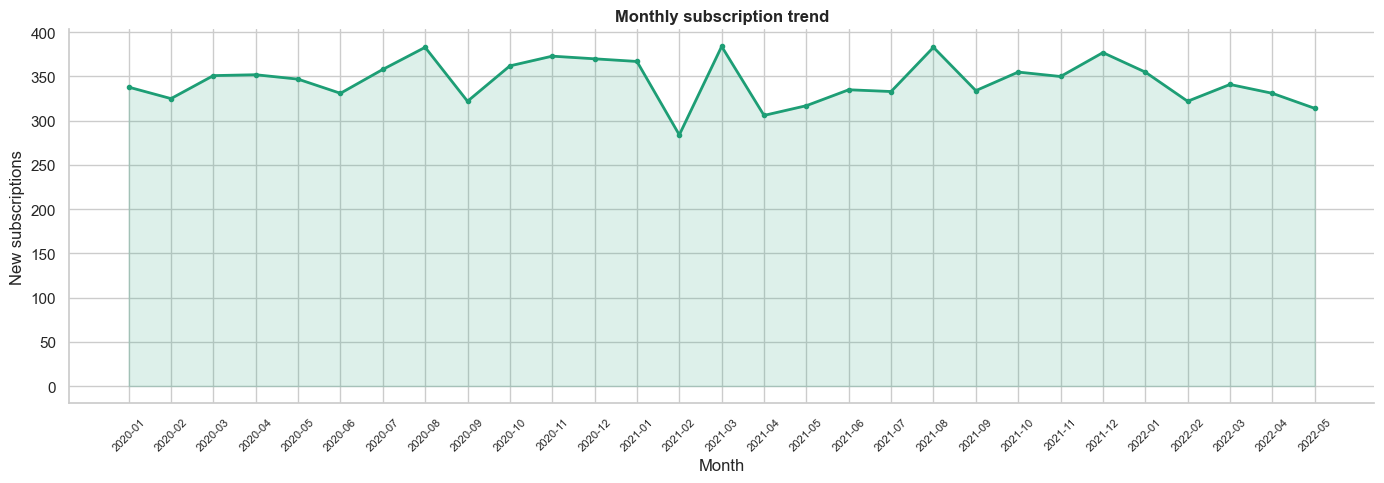

In [12]:
monthly = customers.groupby("sub_month").size().reset_index(name="count")
monthly["label"] = monthly["sub_month"].astype(str)
 
plt.figure(figsize=(14, 5))
plt.plot(monthly["label"], monthly["count"], color="#1D9E75", linewidth=2, marker="o", markersize=3)
plt.fill_between(monthly["label"], monthly["count"], alpha=0.15, color="#1D9E75")
plt.title("Monthly subscription trend", fontweight="bold")
plt.xlabel("Month")
plt.ylabel("New subscriptions")
plt.xticks(rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

Top 15 countries by customer count

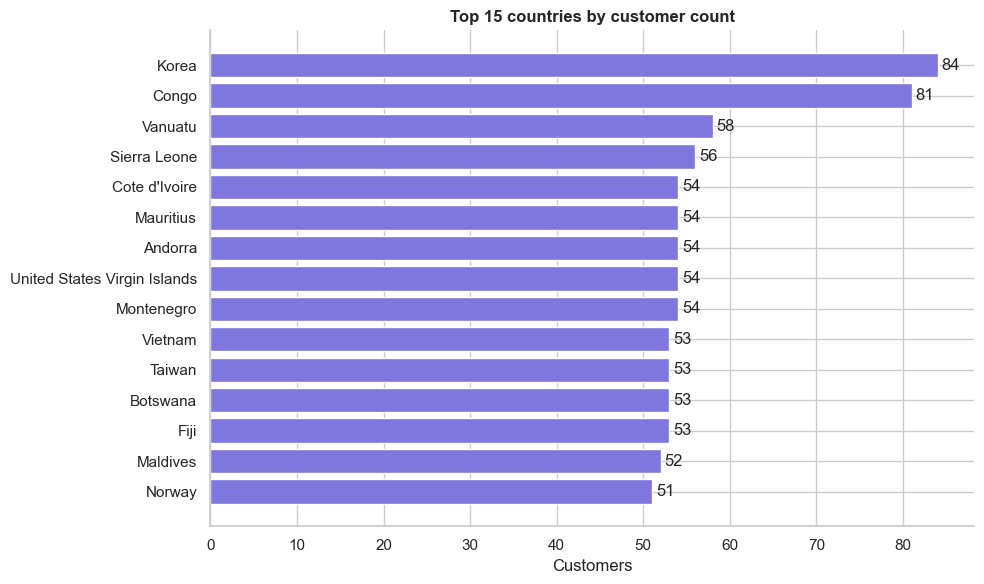

In [13]:
top_countries = customers["Country"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(top_countries.index[::-1], top_countries.values[::-1], color="#7F77DD")
plt.bar_label(bars, padding=3)
plt.title("Top 15 countries by customer count", fontweight="bold")
plt.xlabel("Customers")
plt.tight_layout()
plt.show()

Leads

Lead sources

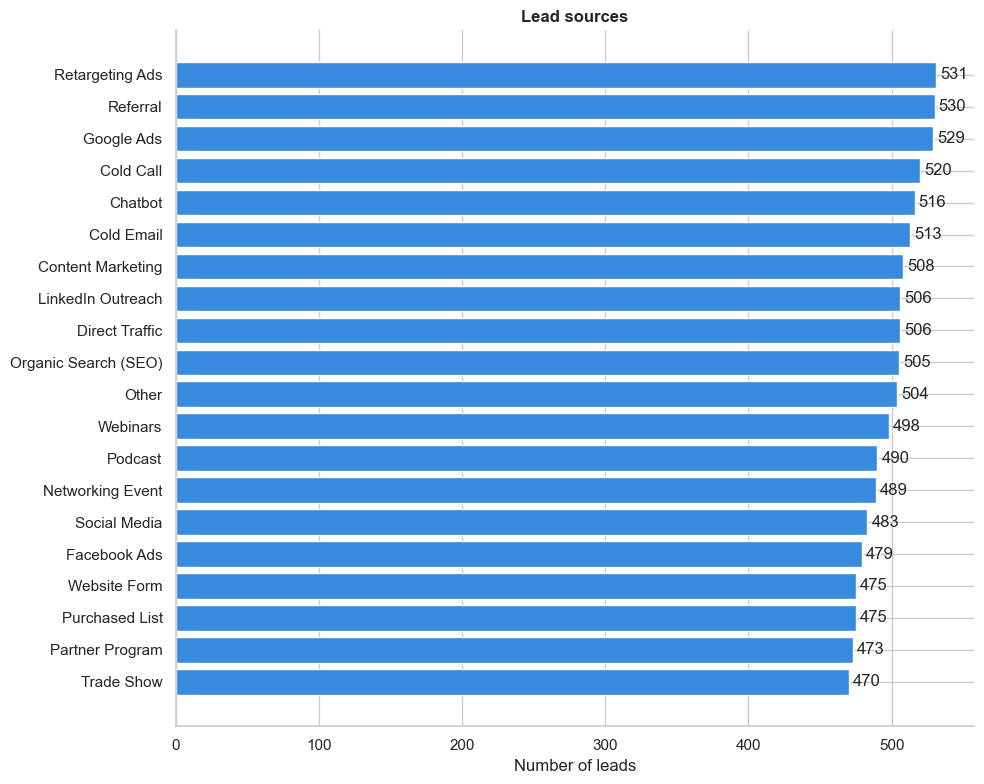

In [14]:
source_counts = leads["Source"].value_counts().sort_values()
 
plt.figure(figsize=(10, 8))
bars = plt.barh(source_counts.index, source_counts.values, color="#378ADD")
plt.bar_label(bars, padding=3)
plt.title("Lead sources", fontweight="bold")
plt.xlabel("Number of leads")
plt.tight_layout()
plt.show()

Deal stage distribution

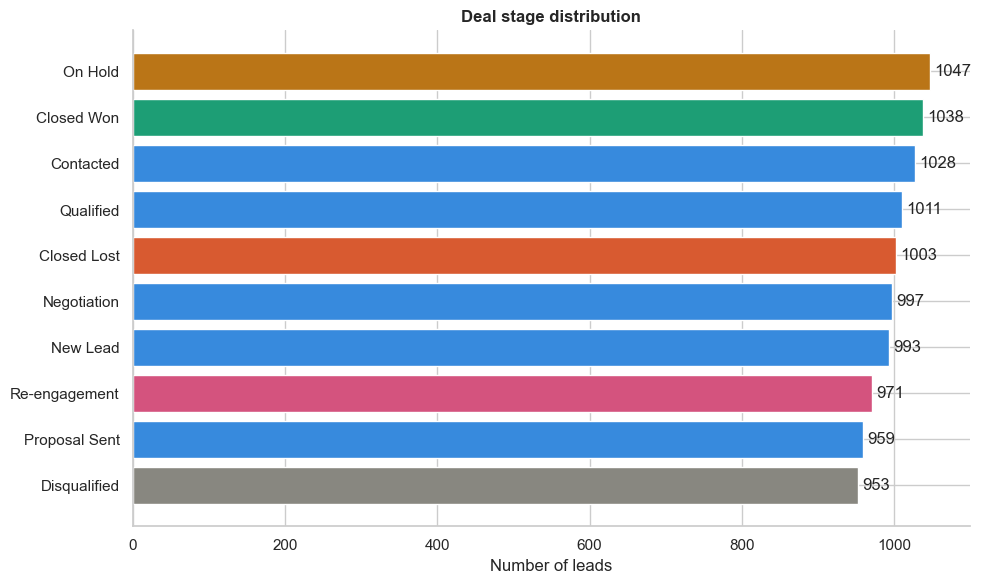

In [15]:
stage_counts = leads["Deal Stage"].value_counts()
 
stage_colors = {
    "Closed Won":   "#1D9E75",
    "Closed Lost":  "#D85A30",
    "Disqualified": "#888780",
    "On Hold":      "#BA7517",
    "Re-engagement":"#D4537E",
}
bar_colors = [stage_colors.get(s, "#378ADD") for s in stage_counts.index]
 
plt.figure(figsize=(10, 6))
bars = plt.barh(stage_counts.index[::-1], stage_counts.values[::-1], color=bar_colors[::-1])
plt.bar_label(bars, padding=3)
plt.title("Deal stage distribution", fontweight="bold")
plt.xlabel("Number of leads")
plt.tight_layout()
plt.show()

Organizations

Top 15 industries

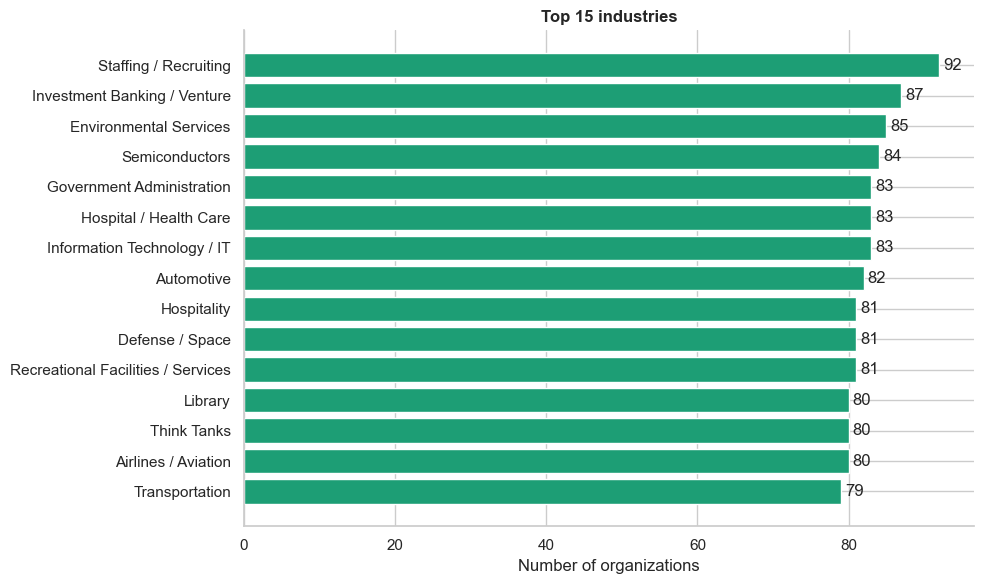

In [16]:
top_industries = organizations["Industry"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(top_industries.index[::-1], top_industries.values[::-1], color="#1D9E75")
plt.bar_label(bars, padding=3)
plt.title("Top 15 industries", fontweight="bold")
plt.xlabel("Number of organizations")
plt.tight_layout()
plt.show()

Employee count distribution

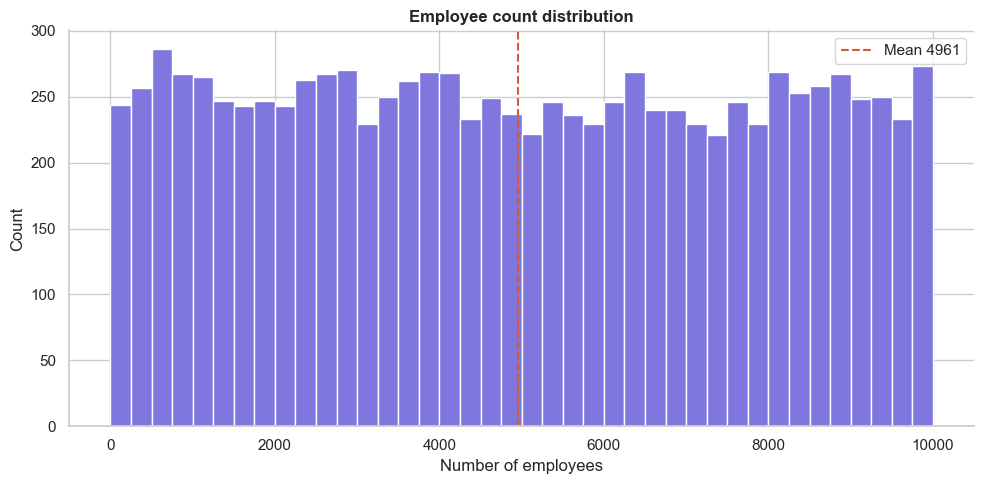

In [17]:
plt.figure(figsize=(10, 5))
plt.hist(organizations["Number of employees"].dropna(), bins=40, color="#7F77DD", edgecolor="white")
plt.axvline(organizations["Number of employees"].mean(), color="#D85A30", linestyle="--",
            label=f"Mean {organizations['Number of employees'].mean():.0f}")
plt.title("Employee count distribution", fontweight="bold")
plt.xlabel("Number of employees")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Founding year distribution

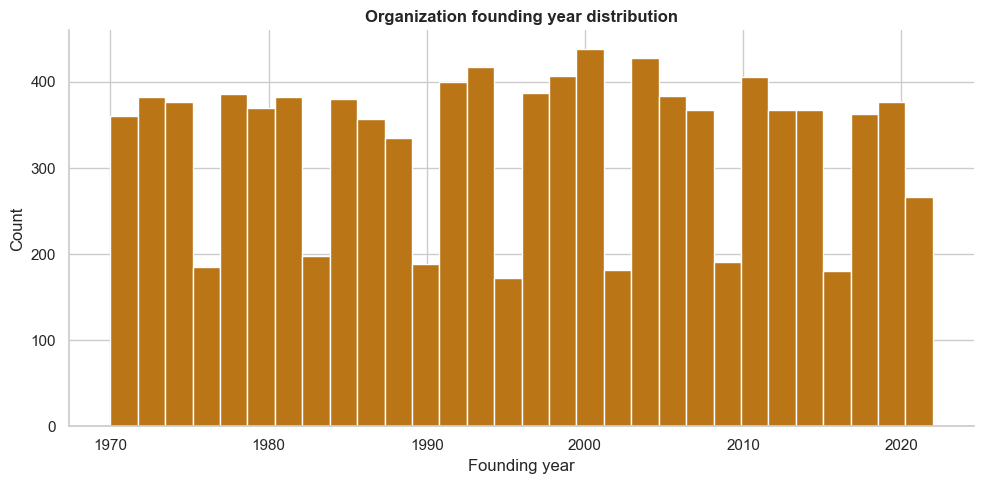

In [18]:
plt.figure(figsize=(10, 5))
plt.hist(organizations["Founded"].dropna(), bins=30, color="#BA7517", edgecolor="white")
plt.title("Organization founding year distribution", fontweight="bold")
plt.xlabel("Founding year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

Top 15 countries

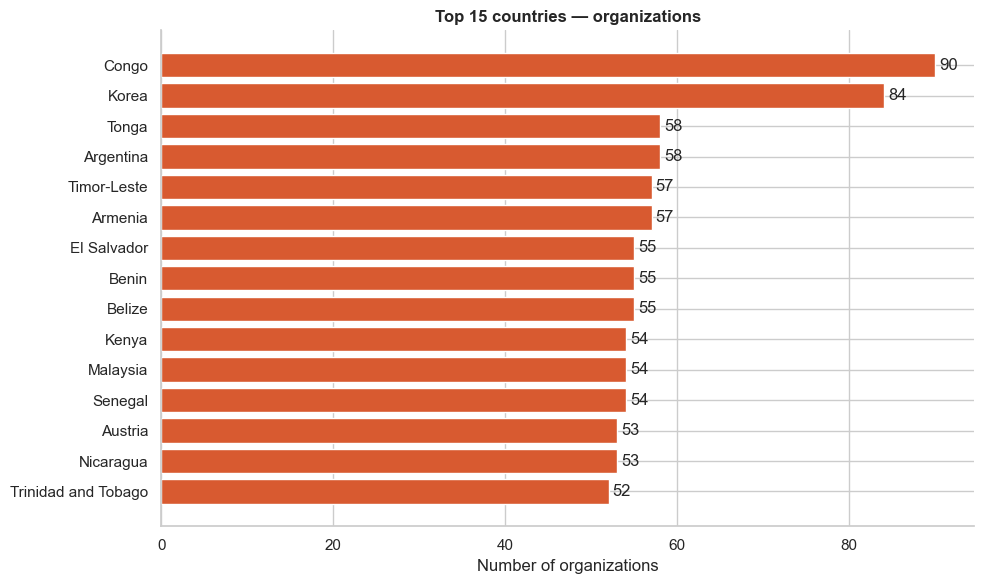

In [19]:
top_org_countries = organizations["Country"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(top_org_countries.index[::-1], top_org_countries.values[::-1], color="#D85A30")
plt.bar_label(bars, padding=3)
plt.title("Top 15 countries — organizations", fontweight="bold")
plt.xlabel("Number of organizations")
plt.tight_layout()
plt.show()

People

Gender distribution

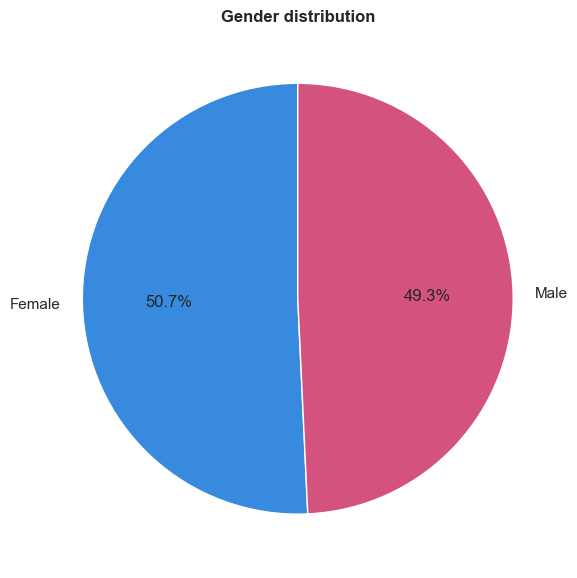

In [20]:
sex_counts = people["Sex"].value_counts()
 
plt.figure(figsize=(6, 6))
plt.pie(sex_counts.values, labels=sex_counts.index, autopct="%1.1f%%",
        colors=["#378ADD", "#D4537E"], startangle=90)
plt.title("Gender distribution", fontweight="bold")
plt.tight_layout()
plt.show()

Age distribution

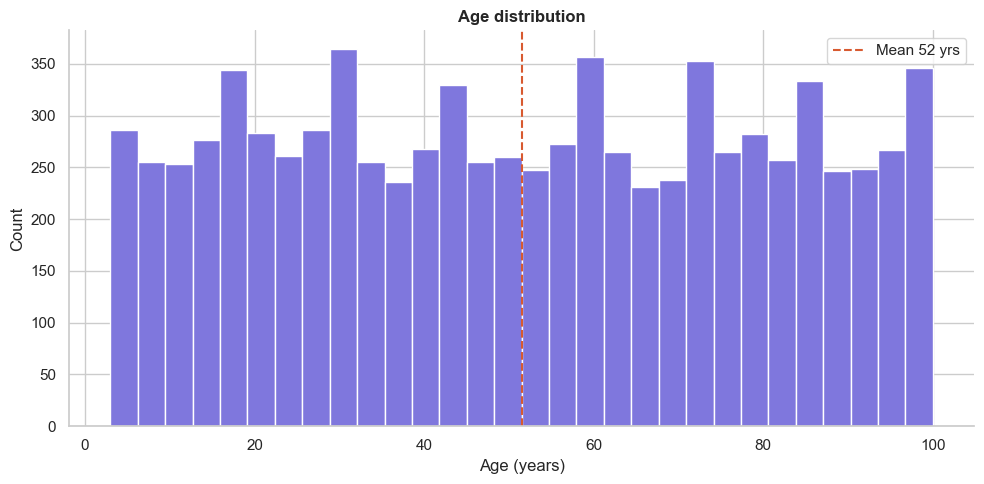

In [21]:
valid_ages = people["age"][(people["age"] >= 0) & (people["age"] <= 100)]
 
plt.figure(figsize=(10, 5))
plt.hist(valid_ages, bins=30, color="#7F77DD", edgecolor="white")
plt.axvline(valid_ages.mean(), color="#D85A30", linestyle="--",
            label=f"Mean {valid_ages.mean():.0f} yrs")
plt.title("Age distribution", fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

Age by gender (box plot)

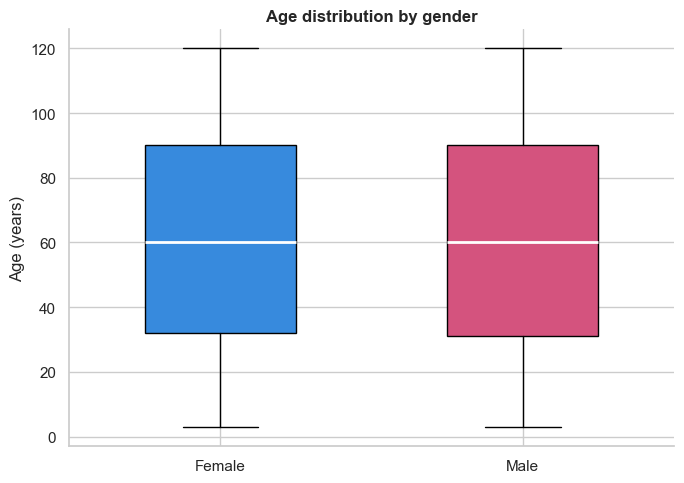

In [22]:
plt.figure(figsize=(7, 5))
data_by_gender = [people.loc[people["Sex"] == g, "age"].dropna().values for g in sex_counts.index]
bp = plt.boxplot(data_by_gender, labels=sex_counts.index, patch_artist=True, widths=0.5,
                 medianprops=dict(color="white", linewidth=2))
colors = ["#378ADD", "#D4537E"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
plt.title("Age distribution by gender", fontweight="bold")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.show()

Top 15 job titles

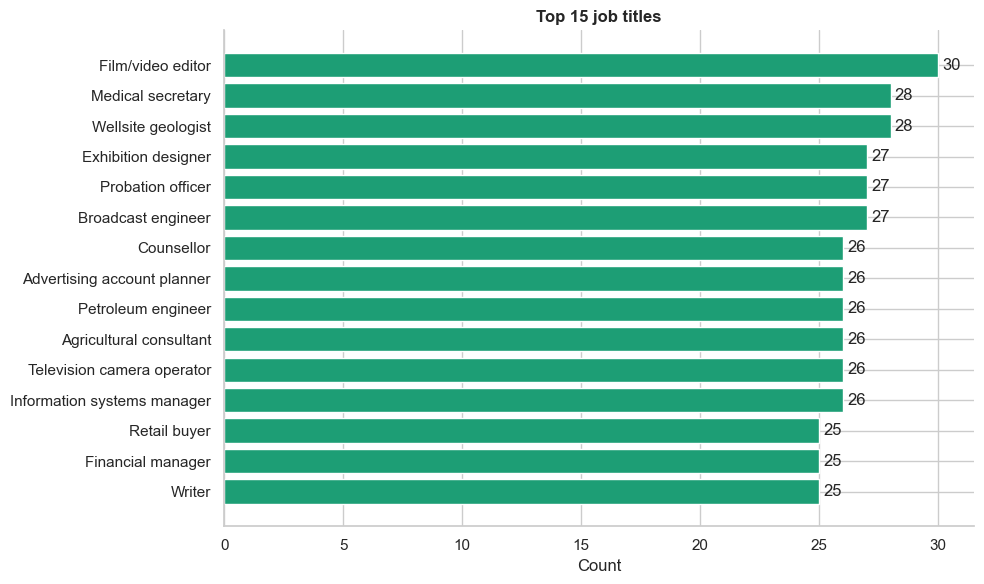

In [23]:
top_jobs = people["Job Title"].value_counts().head(15)
 
plt.figure(figsize=(10, 6))
bars = plt.barh(top_jobs.index[::-1], top_jobs.values[::-1], color="#1D9E75")
plt.bar_label(bars, padding=3)
plt.title("Top 15 job titles", fontweight="bold")
plt.xlabel("Count")
plt.tight_layout()
plt.show()